# Differentially Private Random Forest Classifier - Diabetes Dataset

This notebook implements a Differentially Private Random Forest classifier using `diffprivlib` on the Diabetes dataset and compares its performance with the standard (non-private) model.

## 1. Import Libraries

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, 
    confusion_matrix, 
    f1_score,
    precision_score,
    recall_score,
)
from diffprivlib.models import RandomForestClassifier as DPRandomForestClassifier
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Shared metric collector (repository root): logs training accuracy,
# balanced accuracy and AUROC alongside the metrics already tracked below.
import os as _os
import sys as _sys
_REPO_ROOT = _os.path.abspath(_os.path.join('..', '..'))
if _REPO_ROOT not in _sys.path:
    _sys.path.insert(0, _REPO_ROOT)
from metrics_utils import ExtraMetrics


## 2. Load preprocessed data saved from STD_RF.ipynb

In [2]:
import pickle
# Load the scaled data
with open("../data/processed_data.pkl", "rb") as f: 
    loaded_data = pickle.load(f)

X_train = loaded_data["X_train"]
X_test = loaded_data["X_test"]
y_train = loaded_data["y_train"]
y_test = loaded_data["y_test"]

## 3. Load Baseline Results

In [3]:
# Load baseline results from standard model
try:
    baseline_df = pd.read_csv('output/baseline_results.csv')
    baseline_accuracy = baseline_df['accuracy'].values[0]
    baseline_f1 = baseline_df['f1_score'].values[0]
    print("Baseline results loaded successfully!")
    print(f"Baseline Accuracy: {baseline_accuracy:.4f}")
    print(f"Baseline F1-Score: {baseline_f1:.4f}")
except FileNotFoundError:
    print("Warning: output/baseline_results.csv not found. Please run STD_RF.ipynb first.")
    baseline_accuracy = None
    baseline_f1 = None

Baseline results loaded successfully!
Baseline Accuracy: 0.7373
Baseline F1-Score: 0.7471


## 4. Extract Bounds from Pickle File

In [4]:
# Extract bounds from the loaded data
bounds = loaded_data['bounds']
lower_bound = bounds[0]
upper_bound = bounds[1]

print(f"Bounds extracted from pickle file:")
print(f"Lower bound shape: {lower_bound.shape}")
print(f"Upper bound shape: {upper_bound.shape}")
print(f"Number of features: {len(lower_bound)}")

Bounds extracted from pickle file:
Lower bound shape: (21,)
Upper bound shape: (21,)
Number of features: 21


## 5. Train Differentially Private Random Forest Model

In [5]:
# Define epsilon value for differential privacy
epsilon = 1.0
N_RUNS = 30

# Store per-run metrics for the detailed evaluation at epsilon=1.0
detail_accuracies = []
detail_f1s = []
detail_precisions = []
detail_recalls = []
detail_cms = []  # confusion matrices
 
print(f"Training DP Random Forest {N_RUNS} times with epsilon={epsilon}...")
print("=" * 60)

detail_extra = ExtraMetrics()
for run in range(N_RUNS): 
    seed = run * 10 + 42 # fix sequence for the reproducibility
    # Initialize and train DP Random Forest Classifier
    dp_rf_model = DPRandomForestClassifier(
        n_estimators=20,
        epsilon=epsilon,
        random_state=seed,
        n_jobs=-1,
        max_depth=4, 
        bounds=bounds
    )


    _t0 = time.perf_counter()
    dp_rf_model.fit(X_train, y_train)
    train_time = time.perf_counter() - _t0

    y_dp_pred = dp_rf_model.predict(X_test)
    # Calculate metrics
    dp_accuracy = accuracy_score(y_test, y_dp_pred)
    detail_extra.add(y_test, y_dp_pred, model=dp_rf_model, X=X_test, train_time=train_time)
    dp_f1 = f1_score(y_test, y_dp_pred)
    dp_precision = precision_score(y_test, y_dp_pred)
    dp_recall = recall_score(y_test, y_dp_pred)
    cm = confusion_matrix(y_test, y_dp_pred)

    detail_accuracies.append(dp_accuracy)
    detail_f1s.append(dp_f1)
    detail_precisions.append(dp_precision)
    detail_recalls.append(dp_recall)
    detail_cms.append(cm)


    print(f"  Run {run+1:2d}/{N_RUNS} | Acc: {dp_accuracy:.4f} | F1: {dp_f1:.4f} | Prec: {dp_precision:.4f} | Rec: {dp_recall:.4f}")


print("Added metrics over the detail runs:")
print(detail_extra.describe())

Training DP Random Forest 30 times with epsilon=1.0...
  Run  1/30 | Acc: 0.6877 | F1: 0.6560 | Prec: 0.7300 | Rec: 0.5956


  Run  2/30 | Acc: 0.6985 | F1: 0.6752 | Prec: 0.7317 | Rec: 0.6268


  Run  3/30 | Acc: 0.6985 | F1: 0.6756 | Prec: 0.7311 | Rec: 0.6280
  Run  4/30 | Acc: 0.6785 | F1: 0.6389 | Prec: 0.7287 | Rec: 0.5688


  Run  5/30 | Acc: 0.7058 | F1: 0.7005 | Prec: 0.7135 | Rec: 0.6879


  Run  6/30 | Acc: 0.7058 | F1: 0.7017 | Prec: 0.7114 | Rec: 0.6923
  Run  7/30 | Acc: 0.7118 | F1: 0.6984 | Prec: 0.7324 | Rec: 0.6674


...

  Run 24/30 | Acc: 0.6970 | F1: 0.6773 | Prec: 0.7244 | Rec: 0.6359


  Run 25/30 | Acc: 0.7015 | F1: 0.6939 | Prec: 0.7119 | Rec: 0.6768
  Run 26/30 | Acc: 0.6924 | F1: 0.6694 | Prec: 0.7235 | Rec: 0.6229


  Run 27/30 | Acc: 0.7141 | F1: 0.7269 | Prec: 0.6956 | Rec: 0.7612


  Run 28/30 | Acc: 0.6791 | F1: 0.6370 | Prec: 0.7332 | Rec: 0.5630
  Run 29/30 | Acc: 0.7014 | F1: 0.6908 | Prec: 0.7161 | Rec: 0.6673


  Run 30/30 | Acc: 0.7112 | F1: 0.7056 | Prec: 0.7194 | Rec: 0.6923
Added metrics over the detail runs:
  Balanced Acc:   0.6991 ± 0.0159
  AUROC:          0.7769 ± 0.0094
  Train Time (s): 0.0561 ± 0.0046


## 6. Model Evaluation

In [6]:
avg_accuracy = float(np.mean(detail_accuracies))
avg_f1_score = float(np.mean(detail_f1s))
avg_precision = float(np.mean(detail_precisions))
avg_recall = float(np.mean(detail_recalls))

std_accuracy = float(np.std(detail_accuracies))
std_f1_score = float(np.std(detail_f1s))
std_precision = float(np.std(detail_precisions))
std_recall = float(np.std(detail_recalls))

print("=" * 60)
print(f"\nResults over {N_RUNS} runs at epsilon={epsilon}:")
print(f"  Accuracy:  {avg_accuracy:.4f} ± {std_accuracy:.4f}")
print(f"  F1-Score:  {avg_f1_score:.4f} ± {std_f1_score:.4f}")
print(f"  Precision: {avg_precision:.4f} ± {std_precision:.4f}")
print(f"  Recall:    {avg_recall:.4f} ± {std_recall:.4f}")



Results over 30 runs at epsilon=1.0:
  Accuracy:  0.6991 ± 0.0159
  F1-Score:  0.6791 ± 0.0362
  Precision: 0.7259 ± 0.0130
  Recall:    0.6426 ± 0.0683


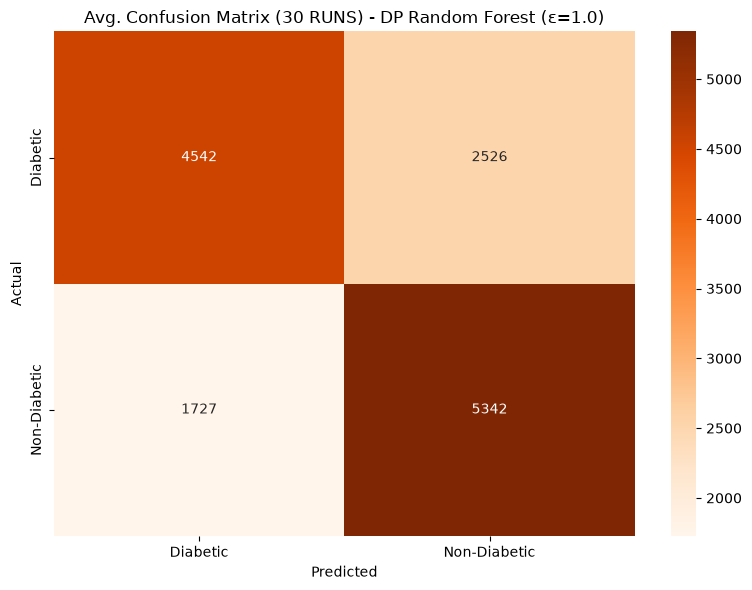


Confusion Matrix:
[[4542 2526]
 [1727 5342]]


In [7]:
avg_cm = np.mean(detail_cms, axis=0).astype(int)

TN = avg_cm[0, 0]
FP = avg_cm[0, 1]
FN = avg_cm[1, 0]
TP = avg_cm[1, 1]

custom_cm = np.array([
    [TP, FN], 
    [FP, TN]
])

plt.figure(figsize=(8, 6))
sns.heatmap(custom_cm, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Diabetic', 'Non-Diabetic'],
            yticklabels=['Diabetic', 'Non-Diabetic'])
plt.title(f'Avg. Confusion Matrix ({N_RUNS} RUNS) - DP Random Forest (ε={epsilon})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print(f"\nConfusion Matrix:")
print(custom_cm)

## 7. Compare with Baseline (Standard Model)

In [8]:
if baseline_accuracy is not None:
    accuracy_loss = baseline_accuracy - avg_accuracy
    f1_loss = baseline_f1 - avg_f1_score
    
    print("=" * 50)
    print("COMPARISON: Standard vs DP Random Forest")
    print("=" * 50)
    print(f"\nStandard Model Accuracy: {baseline_accuracy:.4f}")
    print(f"DP Model Accuracy (avg): {avg_accuracy:.4f}")
    print(f"Accuracy Loss:           {accuracy_loss:.4f} ({accuracy_loss*100:.2f}%)")
    print(f"\nStandard Model F1-Score: {baseline_f1:.4f}")
    print(f"DP Model F1-Score (avg): {avg_f1_score:.4f}")
    print(f"F1 Loss:                 {f1_loss:.4f} ({f1_loss*100:.2f}%)")
else:
    print("Baseline results not available. Run STD_RF.ipynb first.")

COMPARISON: Standard vs DP Random Forest

Standard Model Accuracy: 0.7373
DP Model Accuracy (avg): 0.6991
Accuracy Loss:           0.0382 (3.82%)

Standard Model F1-Score: 0.7471
DP Model F1-Score (avg): 0.6791
F1 Loss:                 0.0680 (6.80%)


## 8. Preparing the Json dump

In [9]:
import json
import os

os.makedirs('output', exist_ok=True)

N_RUNS = 30  # runs per epsilon value
 
parameters = {
    "n_estimators": 20,
    "random_state": "varies (30 seeds per epsilon)",
    "n_jobs": -1,
    "max_depth": 4,
    "n_runs": N_RUNS,
}
 
results_json = {
    "model_type": "Differentially Private Random Forest",
    "n_runs_per_epsilon": N_RUNS,
    "epsilon_results": {}
}

## 9. Epsilon vs Accuracy Analysis

Testing different privacy budget (epsilon) values to observe the trade-off between privacy and accuracy.

In [10]:
epsilon_values = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 4.0, 6.0, 8.0, 10.0]
 
# Store aggregated results
results = {
    'epsilon': [],
    'accuracy_mean': [],
    'accuracy_std': [],
    'f1_score_mean': [],
    'f1_score_std': [],
    'precision_mean': [],
    'precision_std': [],
    'recall_mean': [],
    'recall_std': [],
}
 
print(f"Training DP Random Forest with {N_RUNS} runs per epsilon value...")
print("="*80)
 
for eps in epsilon_values:
    # Collect metrics across N_RUNS runs
    run_accuracies = []
    run_f1s = []
    run_precisions = []
    run_recalls = []
    run_cms = []
 
    extra = ExtraMetrics()
    for run in range(N_RUNS):
        seed = run * 10 + 42  # different seed each run
 
        dp_model = DPRandomForestClassifier(
            n_estimators=20,
            epsilon=eps,
            random_state=seed,
            n_jobs=-1,
            max_depth=4,
            bounds=bounds
        )
        _t0 = time.perf_counter()
        dp_model.fit(X_train, y_train)
        train_time = time.perf_counter() - _t0
        y_pred = dp_model.predict(X_test)
 
        acc = accuracy_score(y_test, y_pred)
        extra.add(y_test, y_pred, model=dp_model, X=X_test, train_time=train_time)
        f1 = f1_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred)
 
        run_accuracies.append(acc)
        run_f1s.append(f1)
        run_precisions.append(prec)
        run_recalls.append(rec)
        run_cms.append(cm.tolist())
        
        # Export model for MIA (only first run per epsilon)
        if run == 0:
            import sys
            import os
            sys.path.append(os.path.abspath(os.path.join('..', '..')))
            from model_exporter import export_model
            export_model(dp_model, f'output/model/dp_rf_model_eps_{eps}.pkl')
 
    # Compute statistics
    acc_mean, acc_std = np.mean(run_accuracies), np.std(run_accuracies)
    f1_mean, f1_std = np.mean(run_f1s), np.std(run_f1s)
    prec_mean, prec_std = np.mean(run_precisions), np.std(run_precisions)
    rec_mean, rec_std = np.mean(run_recalls), np.std(run_recalls)
 
    # Store aggregated results
    results['epsilon'].append(eps)
    # Merge in the added metrics; keys the notebook already tracks are skipped.
    for _key, _value in extra.summary().items():
        results.setdefault(_key, []).append(_value)
    results['accuracy_mean'].append(acc_mean)
    results['accuracy_std'].append(acc_std)
    results['f1_score_mean'].append(f1_mean)
    results['f1_score_std'].append(f1_std)
    results['precision_mean'].append(prec_mean)
    results['precision_std'].append(prec_std)
    results['recall_mean'].append(rec_mean)
    results['recall_std'].append(rec_std)
 
    # Store detailed results in JSON
    results_json["epsilon_results"][str(eps)] = {
        "epsilon": float(eps),
        "n_runs": N_RUNS,
        "accuracy_mean": acc_mean,
        "accuracy_std": acc_std,
        "f1_mean": f1_mean,
        "f1_std": f1_std,
        "precision_mean": prec_mean,
        "precision_std": prec_std,
        "recall_mean": rec_mean,
        "recall_std": rec_std,
        "per_run_accuracies": run_accuracies,
        "per_run_f1s": run_f1s,
        "per_run_precisions": run_precisions,
        "per_run_recalls": run_recalls,
        "per_run_confusion_matrices": run_cms,
        "parameters": parameters.copy()
    }
    results_json["epsilon_results"][str(eps)].update(extra.summary())
    results_json["epsilon_results"][str(eps)].update(extra.per_run())
 
    print(f"ε={eps:5.1f} | Acc: {acc_mean:.4f}±{acc_std:.4f} | "
          f"F1: {f1_mean:.4f}±{f1_std:.4f} | "
          f"Prec: {prec_mean:.4f}±{prec_std:.4f} | "
          f"Rec: {rec_mean:.4f}±{rec_std:.4f}")
 
print("="*80)
print("Training complete!")

Training DP Random Forest with 30 runs per epsilon value...


Model successfully exported to output/model/dp_rf_model_eps_0.1.pkl


ε=  0.1 | Acc: 0.6971±0.0165 | F1: 0.6750±0.0379 | Prec: 0.7264±0.0140 | Rec: 0.6353±0.0711
Model successfully exported to output/model/dp_rf_model_eps_0.2.pkl


ε=  0.2 | Acc: 0.6985±0.0160 | F1: 0.6784±0.0356 | Prec: 0.7253±0.0122 | Rec: 0.6414±0.0670
Model successfully exported to output/model/dp_rf_model_eps_0.4.pkl


ε=  0.4 | Acc: 0.6992±0.0161 | F1: 0.6797±0.0368 | Prec: 0.7251±0.0132 | Rec: 0.6444±0.0699
Model successfully exported to output/model/dp_rf_model_eps_0.6.pkl


...

ε=  2.0 | Acc: 0.6993±0.0158 | F1: 0.6797±0.0359 | Prec: 0.7254±0.0130 | Rec: 0.6440±0.0680
Model successfully exported to output/model/dp_rf_model_eps_4.0.pkl


ε=  4.0 | Acc: 0.6993±0.0158 | F1: 0.6798±0.0359 | Prec: 0.7253±0.0130 | Rec: 0.6442±0.0682
Model successfully exported to output/model/dp_rf_model_eps_6.0.pkl


ε=  6.0 | Acc: 0.6993±0.0158 | F1: 0.6798±0.0359 | Prec: 0.7253±0.0130 | Rec: 0.6442±0.0682
Model successfully exported to output/model/dp_rf_model_eps_8.0.pkl


ε=  8.0 | Acc: 0.6993±0.0158 | F1: 0.6798±0.0359 | Prec: 0.7253±0.0130 | Rec: 0.6442±0.0682
Model successfully exported to output/model/dp_rf_model_eps_10.0.pkl


ε= 10.0 | Acc: 0.6993±0.0158 | F1: 0.6798±0.0359 | Prec: 0.7253±0.0130 | Rec: 0.6442±0.0682
Training complete!


In [11]:
# Save to JSON file
with open('output/dp_rf_report.json', 'w') as f:
    json.dump(results_json, f, indent=4)

print("Results saved to 'output/dp_rf_report.json'")
print(f"Total epsilon values: {len(results_json['epsilon_results'])}")

Results saved to 'output/dp_rf_report.json'
Total epsilon values: 15


In [12]:
results_df = pd.DataFrame(results)
 
if baseline_accuracy is not None:
    results_df['accuracy_loss_mean'] = baseline_accuracy - results_df['accuracy_mean']
    results_df['accuracy_loss_pct'] = results_df['accuracy_loss_mean'] * 100
 
print(f"\nResults Summary ({N_RUNS} runs per epsilon):")
print(results_df.to_string(index=False))


Results Summary (30 runs per epsilon):
 epsilon  accuracy_mean  accuracy_std  f1_score_mean  f1_score_std  precision_mean  precision_std  recall_mean  recall_std  balanced_accuracy_mean  balanced_accuracy_std  roc_auc_mean  roc_auc_std  train_time_mean  train_time_std  accuracy_loss_mean  accuracy_loss_pct
     0.1       0.697110      0.016498       0.674965      0.037913        0.726398       0.013971     0.635304    0.071052                0.697105               0.016502      0.775088     0.010242         0.057978        0.013740            0.040213           4.021265
     0.2       0.698527      0.016046       0.678353      0.035608        0.725272       0.012204     0.641434    0.067015                0.698522               0.016050      0.775984     0.010155         0.051311        0.008218            0.038796           3.879577
     0.4       0.699184      0.016087       0.679662      0.036802        0.725080       0.013173     0.644410    0.069941                0.699180       

## 10. Visualization: Privacy Budget vs Accuracy Loss

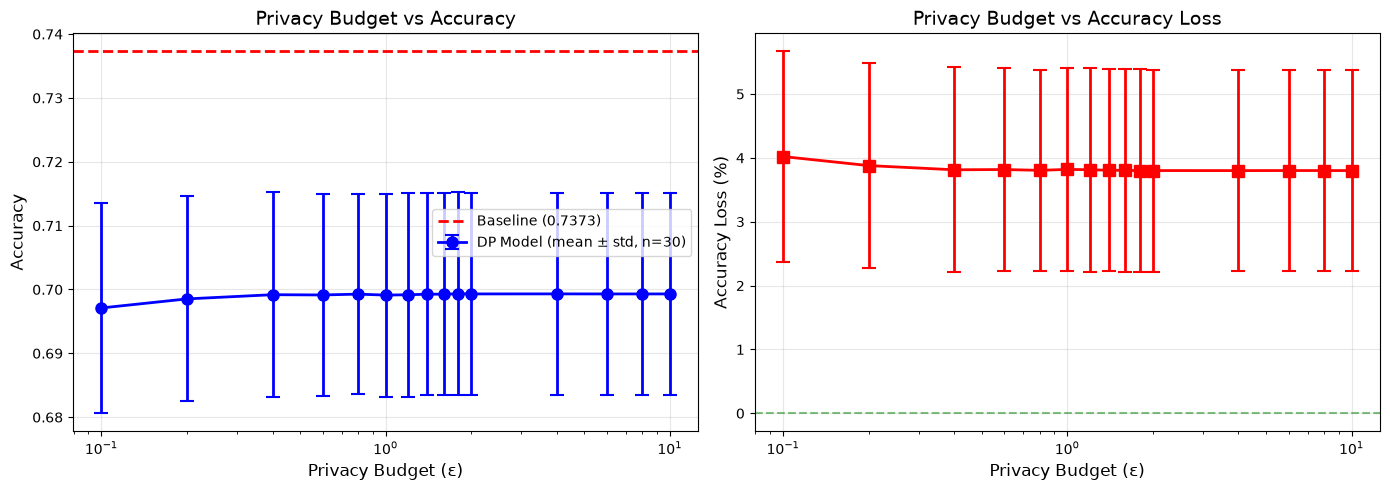


Plot saved as 'output/privacy_accuracy_tradeoff.png'


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Plot 1: Epsilon vs Accuracy (with error bars)
ax1 = axes[0]
ax1.errorbar(
    results_df['epsilon'],
    results_df['accuracy_mean'],
    yerr=results_df['accuracy_std'],
    fmt='bo-', linewidth=2, markersize=8,
    capsize=5, capthick=1.5,
    label=f'DP Model (mean ± std, n={N_RUNS})'
)
if baseline_accuracy is not None:
    ax1.axhline(y=baseline_accuracy, color='r', linestyle='--',
                linewidth=2, label=f'Baseline ({baseline_accuracy:.4f})')
ax1.set_xlabel('Privacy Budget (ε)', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Privacy Budget vs Accuracy', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xscale('log')


# Plot 2: Epsilon vs Accuracy Loss (with error bars)
if baseline_accuracy is not None:
    ax2 = axes[1]
    ax2.errorbar(
        results_df['epsilon'],
        results_df['accuracy_loss_pct'],
        yerr=results_df['accuracy_std'] * 100,
        fmt='rs-', linewidth=2, markersize=8,
        capsize=5, capthick=1.5
    )
    ax2.set_xlabel('Privacy Budget (ε)', fontsize=12)
    ax2.set_ylabel('Accuracy Loss (%)', fontsize=12)
    ax2.set_title('Privacy Budget vs Accuracy Loss', fontsize=14)
    ax2.grid(True, alpha=0.3)
    ax2.set_xscale('log')
    ax2.axhline(y=0, color='g', linestyle='--', alpha=0.5)
 
plt.tight_layout()
plt.savefig('output/privacy_accuracy_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved as 'output/privacy_accuracy_tradeoff.png'")

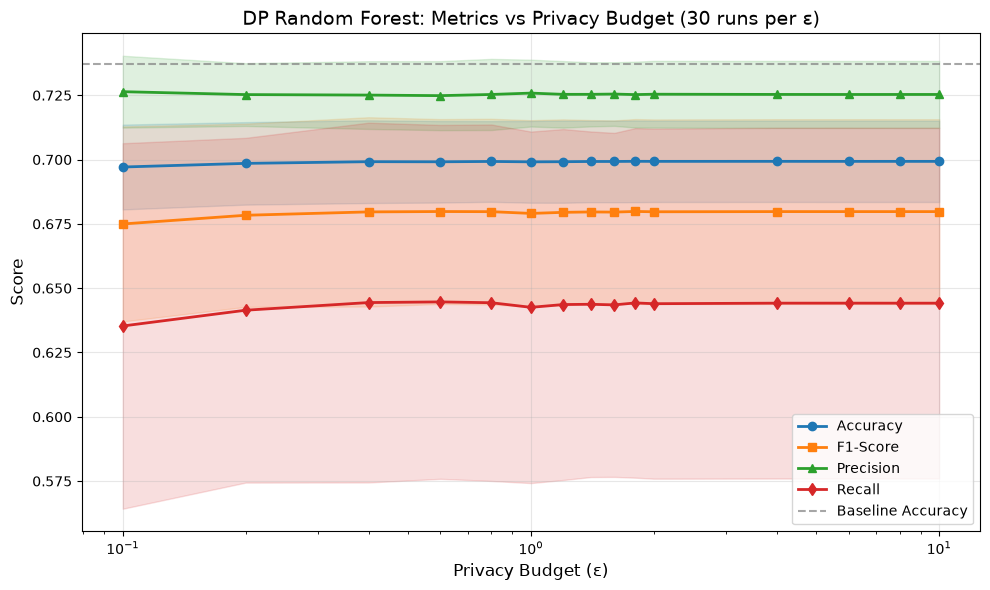

Plot saved as 'output/all_metrics_vs_epsilon.png'


In [14]:
plt.figure(figsize=(10, 6))
 
metrics = [
    ('accuracy_mean', 'accuracy_std', 'Accuracy', 'o-'),
    ('f1_score_mean', 'f1_score_std', 'F1-Score', 's-'),
    ('precision_mean', 'precision_std', 'Precision', '^-'),
    ('recall_mean', 'recall_std', 'Recall', 'd-'),
]
 
for mean_col, std_col, label, fmt in metrics:
    mean_vals = results_df[mean_col].values
    std_vals = results_df[std_col].values
    eps_vals = results_df['epsilon'].values
 
    line = plt.plot(eps_vals, mean_vals, fmt, label=label, linewidth=2)
    color = line[0].get_color()
 
    # Shaded confidence band (mean ± 1 std)
    plt.fill_between(
        eps_vals,
        mean_vals - std_vals,
        mean_vals + std_vals,
        alpha=0.15,
        color=color
    )
 
if baseline_accuracy is not None:
    plt.axhline(y=baseline_accuracy, color='gray', linestyle='--',
                alpha=0.7, label='Baseline Accuracy')
 
plt.xlabel('Privacy Budget (ε)', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title(f'DP Random Forest: Metrics vs Privacy Budget ({N_RUNS} runs per ε)', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.tight_layout()
plt.savefig('output/all_metrics_vs_epsilon.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as 'output/all_metrics_vs_epsilon.png'")

## 11. Save Results

In [15]:
results_df.to_csv('output/dp_results.csv', index=False)
print("DP results saved to 'output/dp_results.csv'")
 
print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
if baseline_accuracy is not None:
    print(f"\nBaseline (Standard RF) Accuracy: {baseline_accuracy:.4f}")
print(f"\nDP Random Forest Results ({N_RUNS} runs per epsilon):")
print(results_df.to_string(index=False))

DP results saved to 'output/dp_results.csv'

FINAL SUMMARY

Baseline (Standard RF) Accuracy: 0.7373

DP Random Forest Results (30 runs per epsilon):
 epsilon  accuracy_mean  accuracy_std  f1_score_mean  f1_score_std  precision_mean  precision_std  recall_mean  recall_std  balanced_accuracy_mean  balanced_accuracy_std  roc_auc_mean  roc_auc_std  train_time_mean  train_time_std  accuracy_loss_mean  accuracy_loss_pct
     0.1       0.697110      0.016498       0.674965      0.037913        0.726398       0.013971     0.635304    0.071052                0.697105               0.016502      0.775088     0.010242         0.057978        0.013740            0.040213           4.021265
     0.2       0.698527      0.016046       0.678353      0.035608        0.725272       0.012204     0.641434    0.067015                0.698522               0.016050      0.775984     0.010155         0.051311        0.008218            0.038796           3.879577
     0.4       0.699184      0.016087       